In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Membaca dataset LQ45
print("Membaca dataset LQ45_Clean.csv...")
df = pd.read_csv('dataset/LQ45_Clean.csv', index_col='timestamp', parse_dates=True)

# Membuang kolom 'volume' sesuai kesepakatan kelompok
if 'volume' in df.columns:
    df = df.drop(columns=['volume'])

print("Dimensi data:", df.shape)
display(df.head())

print("\n=== Ringkasan Statistik Fitur Numerik ===")
display(round(df.describe(), 2))

Membaca dataset LQ45_Clean.csv...
Dimensi data: (649, 17)


,close,open,high,low,change_pct,EMA_21,EMA_99,EMA_200,RSI_14,Stoch_K,MACD,Signal_Line,Upper_BB,Lower_BB,Daily_Return,Target_Price,Target_Direction
timestamp,,,,,,,,,,,,,,,,,
2023-08-23,960.13,962.96,967.66,960.13,-0.29,963.434619,967.192627,968.158320,49.992302,38.527919,-1.913606,-1.509783,971.211860,955.007140,-0.002939,956.34,0
2023-08-24,956.34,960.13,963.71,956.34,-0.39,962.789653,966.975575,968.040725,41.358124,20.137785,-2.230582,-1.653943,970.554511,954.369489,-0.003947,956.72,1
2023-08-25,956.72,956.34,958.71,951.95,0.04,962.237867,966.770463,967.928081,47.923205,24.511819,-2.423192,-1.807793,970.714025,953.954975,0.000397,958.28,1
2023-08-28,958.28,956.80,962.74,956.80,0.16,961.878061,966.600654,967.832080,41.594203,32.528263,-2.422038,-1.930642,970.736453,953.594547,0.001631,964.03,1
2023-08-29,964.03,958.28,965.43,958.28,0.60,962.073691,966.549241,967.794249,52.191476,62.076053,-1.934843,-1.931482,970.550878,953.621122,0.006000,963.92,0



=== Ringkasan Statistik Fitur Numerik ===


,close,open,high,low,change_pct,EMA_21,EMA_99,EMA_200,RSI_14,Stoch_K,MACD,Signal_Line,Upper_BB,Lower_BB,Daily_Return,Target_Price,Target_Direction
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,862.60,864.02,869.40,856.93,-0.05,866.73,877.86,889.87,48.86,50.50,-2.66,-2.55,899.29,834.09,-0.00,862.12,0.49
std,83.78,83.37,83.01,84.58,1.26,78.88,69.48,62.83,16.83,31.08,10.91,10.23,74.00,88.04,0.01,84.10,0.50
min,657.88,651.91,665.05,647.94,-9.09,695.94,765.24,790.33,7.98,0.00,-30.09,-27.52,750.73,631.15,-0.09,651.09,0.00
25%,798.15,800.78,804.53,792.62,-0.71,798.71,801.14,821.61,36.43,21.93,-12.30,-12.08,835.33,769.85,-0.01,797.11,0.00
50%,865.06,867.25,871.30,858.39,-0.01,870.72,903.60,918.40,49.40,51.18,-1.51,-1.11,905.79,840.20,-0.00,864.77,0.00
75%,935.34,936.80,941.72,930.66,0.62,938.83,939.95,950.11,61.30,78.82,6.34,5.79,970.55,908.18,0.01,935.06,1.00
max,1011.60,1016.24,1017.38,1003.32,5.64,995.32,974.48,968.16,90.36,100.00,21.10,18.95,1030.33,980.82,0.06,1011.60,1.00


C:\Users\User\AppData\Local\Temp\ipykernel_1264\3315038694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target_Direction', data=df, palette='Set2')


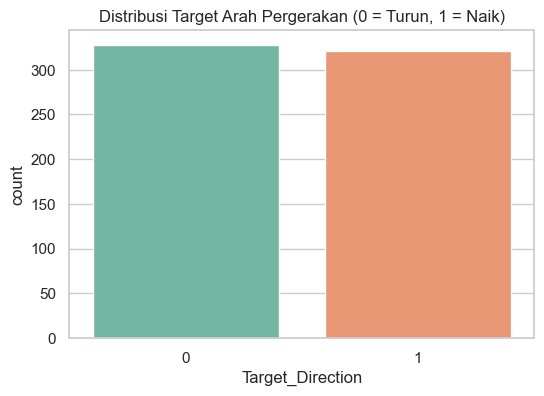

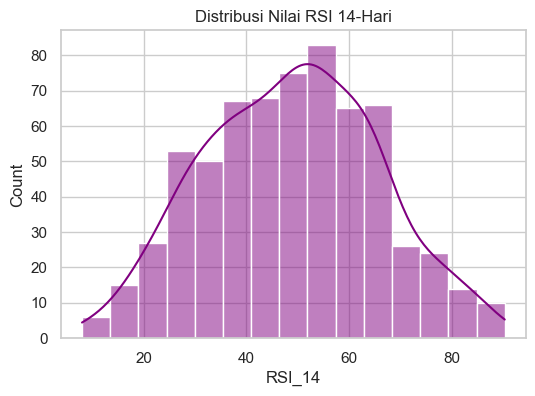

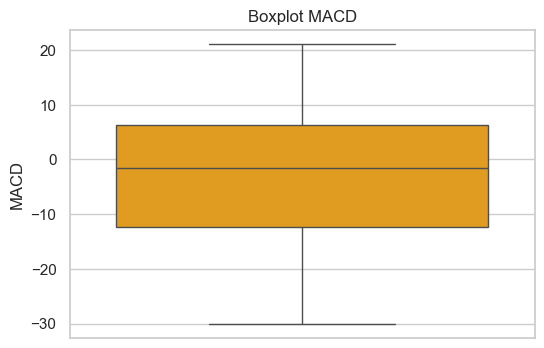


=== Matriks Korelasi ===


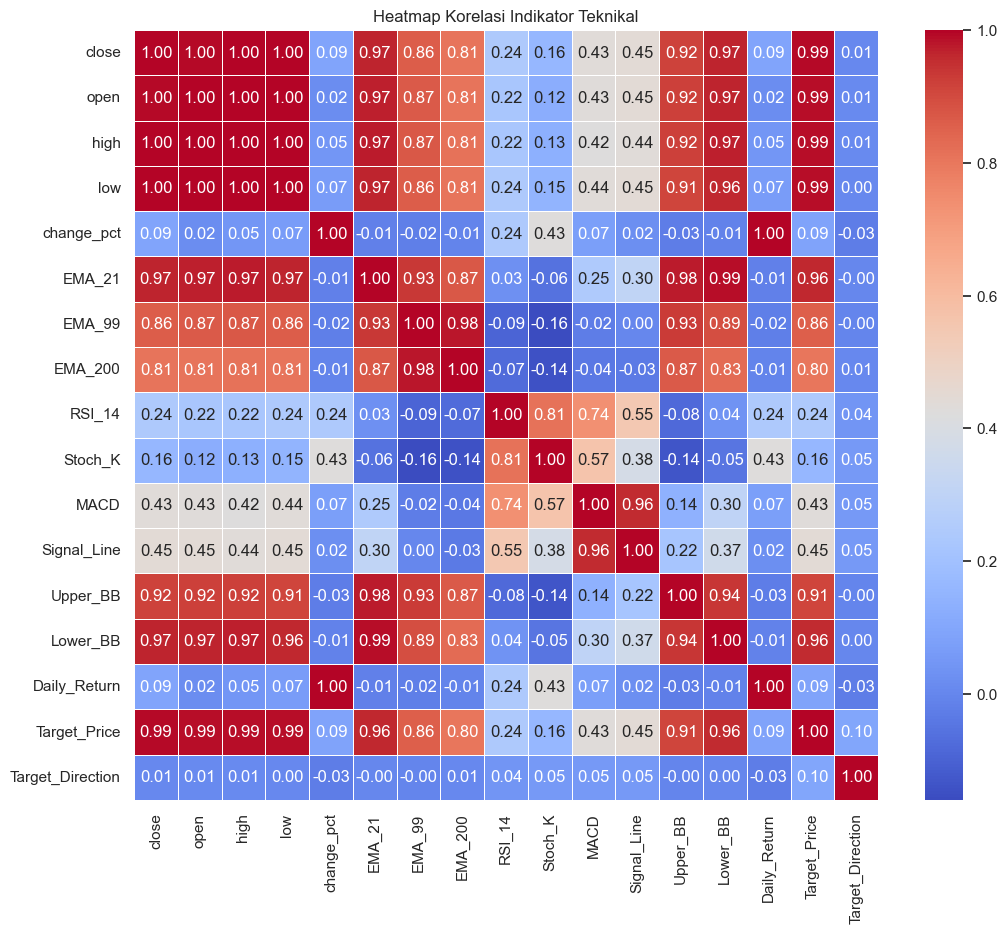

In [3]:
# 1. Distribusi Target (Naik vs Turun)
plt.figure(figsize=(6, 4))
sns.countplot(x='Target_Direction', data=df, palette='Set2')
plt.title('Distribusi Target Arah Pergerakan (0 = Turun, 1 = Naik)')
plt.show()

# 2. Distribusi Indikator Teknikal (Contoh: RSI)
plt.figure(figsize=(6, 4))
sns.histplot(x='RSI_14', data=df, kde=True, color='purple')
plt.title('Distribusi Nilai RSI 14-Hari')
plt.show()

# 3. Boxplot untuk mendeteksi Outlier pada MACD
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['MACD'], color='orange')
plt.title('Boxplot MACD')
plt.show()

# 4. Correlation Heatmap
print("\n=== Matriks Korelasi ===")
plt.figure(figsize=(12, 10))
corr = round(df.corr(numeric_only=True), 4)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Indikator Teknikal')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Memisahkan Fitur (X) dan Target (y)
# Kita drop Target_Price karena tidak dipakai untuk klasifikasi arah
X = df.drop(columns=['Target_Direction', 'Target_Price'])
y = df['Target_Direction']

# Split Data (80% Train, 20% Test) - Time series sebaiknya shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Normalization dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 519
Jumlah data testing: 130


In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("Melatih model SVC dan mencari hyperparameter terbaik...")

# GridSearch persis seperti di train.py
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# probability=True WAJIB agar kita bisa membuat grafik ROC-AUC nanti
svm_grid = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42), 
    param_grid, 
    refit=True, 
    cv=5,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

# Mengambil model terbaik
model = svm_grid.best_estimator_
print(f"\nParameter terbaik yang ditemukan: {svm_grid.best_params_}")

Melatih model SVC dan mencari hyperparameter terbaik...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Parameter terbaik yang ditemukan: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}


=== EVALUASI MODEL SVC ===
Accuracy  : 0.5077
Precision : 0.4717
Recall    : 0.4098
F1-Score  : 0.4386

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.53      0.59      0.56        69
           1       0.47      0.41      0.44        61

    accuracy                           0.51       130
   macro avg       0.50      0.50      0.50       130
weighted avg       0.50      0.51      0.50       130



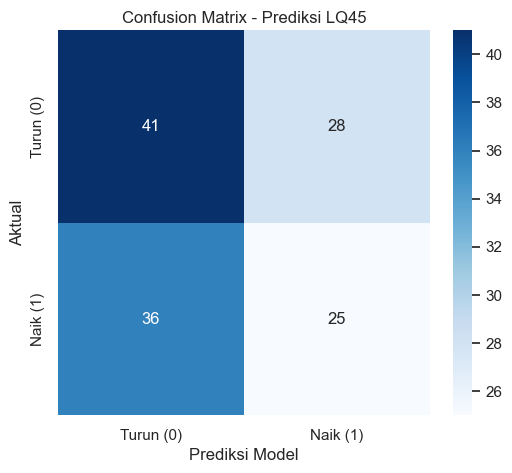

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Prediksi data testing
y_pred = model.predict(X_test_scaled)
# Prediksi probabilitas untuk ROC-AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1] 

# Menghitung Metrik
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
af1 = f1_score(y_test, y_pred)

print("=== EVALUASI MODEL SVC ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {af1:.4f}\n")

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Turun (0)', 'Naik (1)'], 
            yticklabels=['Turun (0)', 'Naik (1)'])
plt.title('Confusion Matrix - Prediksi LQ45')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual')
plt.show()

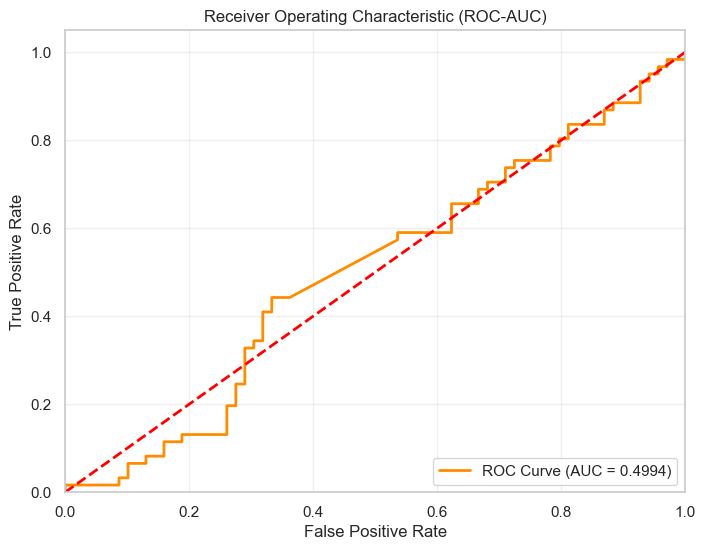

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

# Menghitung False Positive Rate, True Positive Rate, dan nilai AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC-AUC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [8]:
from sklearn.model_selection import cross_val_score, KFold

print("=== 5-FOLD CROSS VALIDATION ===")
# Menggunakan KFold untuk memvalidasi model di seluruh dataset
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Gunakan StandardScaler pada seluruh data X (khusus untuk simulasi CV)
X_scaled_all = scaler.fit_transform(X)

# Melakukan evaluasi
cv_scores = cross_val_score(model, X_scaled_all, y, cv=kfold, scoring='accuracy')

print(f"Akurasi tiap putaran (5 Folds): {np.round(cv_scores, 4)}")
print(f"Rata-rata Akurasi             : {cv_scores.mean():.4f}")
print(f"Standar Deviasi               : {cv_scores.std():.4f}")

=== 5-FOLD CROSS VALIDATION ===
Akurasi tiap putaran (5 Folds): [0.4923 0.5692 0.5    0.5385 0.4806]
Rata-rata Akurasi             : 0.5161
Standar Deviasi               : 0.0329


In [9]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Asumsi y_test dan y_pred sudah ada dari sel sebelumnya
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
af1 = f1_score(y_test, y_pred)

# Membuat Evaluation Matrix dalam bentuk Pandas DataFrame
evaluation_matrix = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Nilai': [acc, pre, rec, af1],
    'Penjelasan Singkat': [
        'Proporsi tebakan benar (Naik & Turun) secara keseluruhan',
        'Dari semua tebakan Naik, berapa persen yang BENAR Naik',
        'Dari semua hari yang ASLINYA Naik, berapa persen yang BERHASIL ditebak',
        'Keseimbangan antara Precision dan Recall'
    ]
})

# Menambahkan format persentase agar lebih enak dilihat
evaluation_matrix['Persentase (%)'] = (evaluation_matrix['Nilai'] * 100).round(2)

print("=== EVALUATION METRICS MATRIX ===")
display(evaluation_matrix[['Metrik', 'Nilai', 'Persentase (%)', 'Penjelasan Singkat']])

=== EVALUATION METRICS MATRIX ===


,Metrik,Nilai,Persentase (%),Penjelasan Singkat
0,Accuracy,0.507692,50.77,Proporsi tebakan benar (Naik & Turun) secara k...
1,Precision,0.471698,47.17,"Dari semua tebakan Naik, berapa persen yang BE..."
2,Recall,0.409836,40.98,"Dari semua hari yang ASLINYA Naik, berapa pers..."
3,F1-Score,0.438596,43.86,Keseimbangan antara Precision dan Recall
